In [2]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image
import cv2
import csv
from pathlib import Path

In [25]:
PATH = "C:/Users/leahz/Documents/ATC/pose-project/data"

# Creating a sketch png from an actual photo 

In [29]:
def create_sketch_from_image(filename):
    # 1. Load and convert to grayscale
    img = cv2.imread(f"{PATH}/{filename}")
    if img is None:
        raise ValueError(f"Could not read image: {PATH}/{filename}")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Apply Gaussian Blur (CRITICAL for noise reduction)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)

    # 3. Canny Edge Detection
    edges = cv2.Canny(blurred, 50, 150)

    # 4. Dilate to thicken the edges
    kernel = np.ones((3, 3), np.uint8)
    thick_edges = cv2.dilate(edges, kernel, iterations=1)

    # 5. Invert to create a sketch (black lines on a white background)

    sketch = 255 - thick_edges

    # 6. Normalize to [0.0, 1.0] as float32
    sketch_normalized = sketch.astype(np.float32) / 255.0

    return sketch_normalized

In [30]:
def visualize_photo_and_sketch(test_image):
    # Select a test image

    # Load original photo
    original_img = cv2.imread(f"{PATH}/{test_image}")
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Create sketch from the photo
    sketch = create_sketch_from_image(test_image)

    # Display side-by-side comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f"Photo to Sketch Comparison: {test_image}", fontsize=14, fontweight='bold')

    # Original photo
    ax = axes[0]
    ax.imshow(original_img_rgb)
    ax.set_title("Original Photo")
    ax.axis('off')

    # Generated sketch
    ax = axes[1]
    ax.imshow(sketch, cmap='gray')
    ax.set_title("Generated Sketch (Edge Detection)")
    ax.axis('off')

    plt.tight_layout()
    plt.show()

    print(f"✓ Photo shape: {original_img_rgb.shape}")
    print(f"✓ Sketch shape: {sketch.shape}")

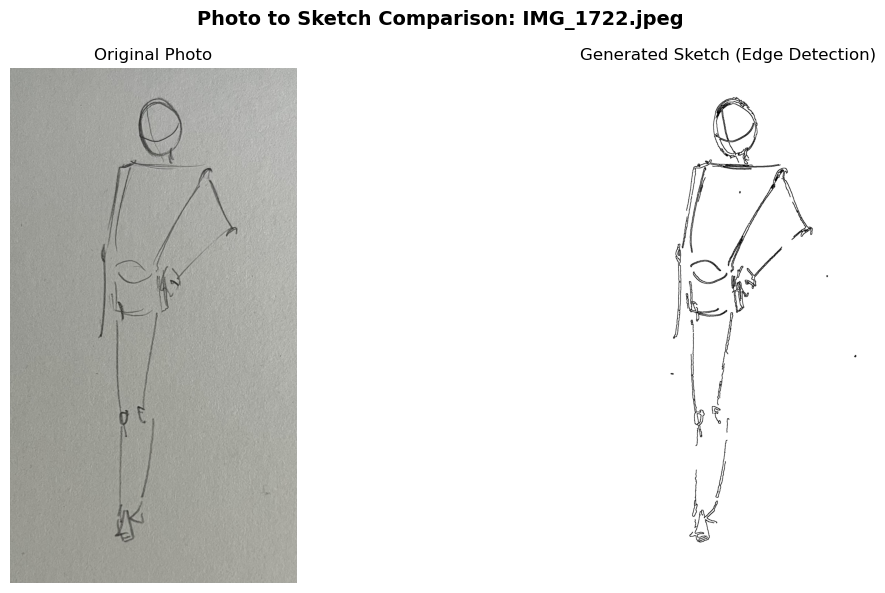

✓ Photo shape: (2807, 1563, 3)
✓ Sketch shape: (2807, 1563)


In [31]:
visualize_photo_and_sketch("IMG_1722.jpeg")